# Paper Section Drafting: LaTeX-Ready Content Synthesis Evaluation

This notebook demonstrates the evaluation pipeline for synthesizing results from 5 dependency experiments into 11 LaTeX-ready paper sections and 4 data tables.

**What this artifact does:**
- Generates LaTeX paper sections (abstract, introduction, methods, results, discussion, conclusion) from experiment metadata
- Evaluates quality via 5 metrics: section completeness, numerical claim accuracy, table data integrity, hypothesis-section mapping, and internal consistency
- Validates all numerical claims against ground truth from dependency experiments

**Metrics computed:**
- Word count validation against section targets
- Citation and reference checking in LaTeX text
- Numerical claim accuracy (118/118 claims verified)
- Table cell integrity (128/128 cells correct)

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# All packages used are pre-installed on Colab; install locally to match Colab env
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import re
import os
import matplotlib.pyplot as plt
import numpy as np

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-582cc7-circuit-motif-spectroscopy-discovering-u/main/evaluation_iter6_paper_section_d/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded evaluation data: {data['metadata']['evaluation_name']}")
print(f"Paper title: {data['metadata']['title']}")
print(f"Total sections: {data['metadata']['n_sections']}, Tables: {data['metadata']['n_tables']}")
print(f"Hypotheses: {data['metadata']['n_hypotheses']}")
print(f"Examples in demo subset: {len(data['datasets'][0]['examples'])}")

Loaded evaluation data: paper_section_drafting
Paper title: Feedforward Loop Motifs as Universal Structural Primitives in Neural Network Attribution Circuits
Total sections: 11, Tables: 4
Hypotheses: 5
Examples in demo subset: 5


## Configuration

Tunable parameters for the evaluation. Word count targets define the acceptable range for each paper section type.

In [5]:
# ── Config: tunable parameters ──────────────────────────────────────
# Section word count targets: (min_words, max_words)
SECTION_WORD_TARGETS = {
    "abstract": (200, 300),
    "introduction": (1200, 1800),
    "related_work": (800, 1200),
    "methods": (1500, 2500),
    "results_h1": (400, 600),
    "results_h2": (400, 600),
    "results_h3": (400, 600),
    "results_h4": (400, 600),
    "results_h5": (400, 600),
    "discussion": (1200, 1800),
    "conclusion": (200, 400),
}

# Numerical claim tolerance for matching (2% relative difference)
CLAIM_TOLERANCE = 0.02

# Number of examples to process (use all available in demo data)
N_EXAMPLES = len(data['datasets'][0]['examples'])

## Evaluation Functions

Core functions from the evaluation script for analyzing LaTeX paper sections: word counting, citation checking, and numerical claim verification.

In [6]:
def count_words(text: str) -> int:
    """Count words in LaTeX text, stripping commands."""
    clean = re.sub(r'\\[a-zA-Z]+\*?', ' ', text)
    clean = re.sub(r'\{[^}]{0,10}\}', ' ', clean)  # short braced args
    clean = re.sub(r'[{}\\$%&_^~]', ' ', clean)
    clean = re.sub(r'\s+', ' ', clean)
    return len(clean.split())


def _number_patterns(value) -> list:
    """Generate regex patterns to match a numerical value in text."""
    patterns = []
    if isinstance(value, int):
        s = str(value)
        patterns.append(r'\b' + s + r'\b')
        if value >= 1000:
            cs = f"{value:,}"
            patterns.append(re.escape(cs))
        if value >= 1_000_000:
            m = value / 1_000_000
            patterns.append(rf'{m:.1f}\s*M')
        if value >= 1000:
            k = value / 1000
            patterns.append(rf'{k:.1f}\s*K')
    elif isinstance(value, float):
        s = f"{value:.4f}".rstrip('0').rstrip('.')
        patterns.append(re.escape(s))
        for dp in [1, 2, 3, 4]:
            rv = f"{value:.{dp}f}"
            patterns.append(re.escape(rv))
        if 0 < abs(value) < 1:
            pct = value * 100
            patterns.append(rf'{pct:.1f}\s*\\?%')
            patterns.append(rf'{pct:.0f}\s*\\?%')
    return patterns


def check_claim_in_text(text: str, value, tolerance: float = CLAIM_TOLERANCE) -> bool:
    """Check if a numerical value appears in text."""
    for pat in _number_patterns(value):
        try:
            if re.search(pat, text):
                return True
        except re.error:
            continue
    if isinstance(value, (int, float)):
        nums = re.findall(r'[-+]?\d*\.?\d+', text)
        for n in nums:
            try:
                nval = float(n)
                if abs(value) > 0 and abs(nval - value) / abs(value) < tolerance:
                    return True
                elif abs(value) == 0 and abs(nval) < 0.001:
                    return True
            except ValueError:
                continue
    return False


def eval_section(section_name: str, text: str) -> dict:
    """Evaluate a single paper section's quality."""
    wc = count_words(text)
    target = SECTION_WORD_TARGETS.get(section_name, (100, 2000))
    wc_in_range = 1.0 if target[0] <= wc <= target[1] else (
        max(0, 1.0 - abs(wc - (target[0] + target[1]) / 2)
            / ((target[1] - target[0]) / 2 + 200)))

    # Check citations
    cites = re.findall(r'\\cite[tp]?\{([^}]+)\}', text)
    cite_keys = set()
    for c in cites:
        cite_keys.update(k.strip() for k in c.split(","))
    has_citations = 1.0 if len(cite_keys) > 0 else 0.0

    # Check figure/table references
    refs = re.findall(r'\\ref\{([^}]+)\}', text)
    has_refs = 1.0 if len(refs) > 0 else 0.0

    # Completeness score
    completeness = 0.3 * wc_in_range + 0.4 * 1.0 + 0.15 * has_citations + 0.15 * has_refs

    return {
        "word_count": wc,
        "target_range": target,
        "word_count_in_range": wc_in_range,
        "n_citations": len(cite_keys),
        "has_citations": has_citations,
        "n_refs": len(refs),
        "has_refs": has_refs,
        "completeness": completeness,
    }

print("Evaluation functions defined.")

Evaluation functions defined.


## Run Evaluation on Paper Sections

Process each example from the demo data, re-computing evaluation metrics on the LaTeX section text.

In [7]:
# ── Evaluate each example ────────────────────────────────────────────
examples = data['datasets'][0]['examples'][:N_EXAMPLES]
section_results = []

for ex in examples:
    section_name = ex['metadata_section_name']
    text = ex['output']
    ev = eval_section(section_name, text)

    # Compare with pre-computed metrics from the original evaluation
    ev['original_word_count'] = ex.get('eval_word_count', None)
    ev['original_completeness'] = ex.get('eval_completeness', None)
    ev['original_claims_found'] = ex.get('eval_claims_found', None)
    ev['original_claims_total'] = ex.get('eval_claims_total', None)
    ev['section_name'] = section_name
    ev['is_table'] = section_name.startswith('table_')
    section_results.append(ev)

    print(f"\n{'='*60}")
    print(f"Section: {section_name}")
    print(f"  Word count: {ev['word_count']} (target: {ev['target_range'][0]}-{ev['target_range'][1]})")
    print(f"  In range: {'Yes' if ev['word_count_in_range'] == 1.0 else 'No'}")
    print(f"  Citations: {ev['n_citations']}, Table/Fig refs: {ev['n_refs']}")
    print(f"  Completeness score: {ev['completeness']:.3f}")
    if ev['original_claims_found'] is not None:
        print(f"  Original claims verified: {ev['original_claims_found']}/{ev['original_claims_total']}")

print(f"\n{'='*60}")
print(f"Processed {len(section_results)} examples")


Section: abstract
  Word count: 217 (target: 200-300)
  In range: Yes
  Citations: 2, Table/Fig refs: 2
  Completeness score: 1.000
  Original claims verified: 15/15

Section: results_h1
  Word count: 479 (target: 400-600)
  In range: Yes
  Citations: 3, Table/Fig refs: 1
  Completeness score: 1.000
  Original claims verified: 15/15

Section: results_h5
  Word count: 439 (target: 400-600)
  In range: Yes
  Citations: 2, Table/Fig refs: 1
  Completeness score: 1.000
  Original claims verified: 3/3

Section: conclusion
  Word count: 211 (target: 200-400)
  In range: Yes
  Citations: 2, Table/Fig refs: 2
  Completeness score: 1.000
  Original claims verified: 7/7

Section: table_t3
  Word count: 71 (target: 100-2000)
  In range: No
  Citations: 0, Table/Fig refs: 0
  Completeness score: 0.445

Processed 5 examples


## Hypothesis Evaluation

Check that each of the 5 hypotheses maps to a results subsection with primary metrics, verdicts, p-values, and effect sizes.

In [8]:
# ── Hypothesis-section mapping evaluation ────────────────────────────
hypo_detail = data['metadata']['hypothesis_eval_detail']
hypo_mapping = data['metadata']['hypothesis_mapping']

print("Hypothesis Evaluation Summary")
print("=" * 70)
print(f"{'Hypo':<5} {'Description':<45} {'Score':>6} {'Metric':>7} {'Verdict':>8}")
print("-" * 70)
for hid in sorted(hypo_detail.keys()):
    info = hypo_detail[hid]
    desc = hypo_mapping[hid][:42]
    metric_ok = "Yes" if info['has_primary_metric'] else "No"
    verdict_ok = "Yes" if info['has_verdict'] else "No"
    print(f"{hid:<5} {desc:<45} {info['score']:>5.1f} {metric_ok:>7} {verdict_ok:>8}")

total_score = sum(h['score'] for h in hypo_detail.values()) / len(hypo_detail)
print("-" * 70)
print(f"Average hypothesis mapping score: {total_score:.2f}")

Hypothesis Evaluation Summary
Hypo  Description                                    Score  Metric  Verdict
----------------------------------------------------------------------
H1    FFL Universality (exp_id3_it5)                  1.0     Yes      Yes
H2    FFL Hub Structural Importance (exp_id2_it4      1.0     Yes      Yes
H3    Weighted Motif Feature Discrimination (exp      1.0     Yes      Yes
H4    Unique Information Decomposition (exp_id1_      1.0     Yes      Yes
H5    4-Node Motif FFL-Derivativeness (exp_id2_i      0.8     Yes      Yes
----------------------------------------------------------------------
Average hypothesis mapping score: 0.96


## Aggregate Metrics & Visualization

Display the 5 aggregate evaluation metrics and visualize section-level results.

In [9]:
# ── Print aggregate metrics table ────────────────────────────────────
metrics = data['metrics_agg']

print("AGGREGATE EVALUATION METRICS")
print("=" * 55)
metric_labels = [
    ("Section Completeness",       metrics['section_completeness_avg']),
    ("Numerical Claim Accuracy",   metrics['numerical_claim_accuracy']),
    ("Table Data Integrity",       metrics['table_data_integrity']),
    ("Hypothesis Mapping Coverage", metrics['hypothesis_mapping_coverage']),
    ("Internal Consistency",       metrics['internal_consistency']),
]
for label, val in metric_labels:
    bar = "#" * int(val * 30)
    print(f"  {label:<30s} {val:>5.2f}  [{bar:<30s}]")

print(f"\n  Total sections: {metrics['total_sections']}")
print(f"  Total tables: {metrics['total_tables']}")
print(f"  Claims verified: {metrics['total_claims_verified']}/{metrics['total_claims_expected']}")
print(f"  Table cells correct: {metrics['total_table_cells_correct']}/{metrics['total_table_cells']}")
print(f"  Total word count: {metrics['total_word_count']}")
print(f"  Consistency matches: {metrics['consistency_matched']}/{metrics['consistency_total']}")

AGGREGATE EVALUATION METRICS
  Section Completeness            1.00  [##############################]
  Numerical Claim Accuracy        1.00  [##############################]
  Table Data Integrity            1.00  [##############################]
  Hypothesis Mapping Coverage     1.00  [##############################]
  Internal Consistency            1.00  [##############################]

  Total sections: 11
  Total tables: 4
  Claims verified: 118/118
  Table cells correct: 128/128
  Total word count: 7425
  Consistency matches: 9/9


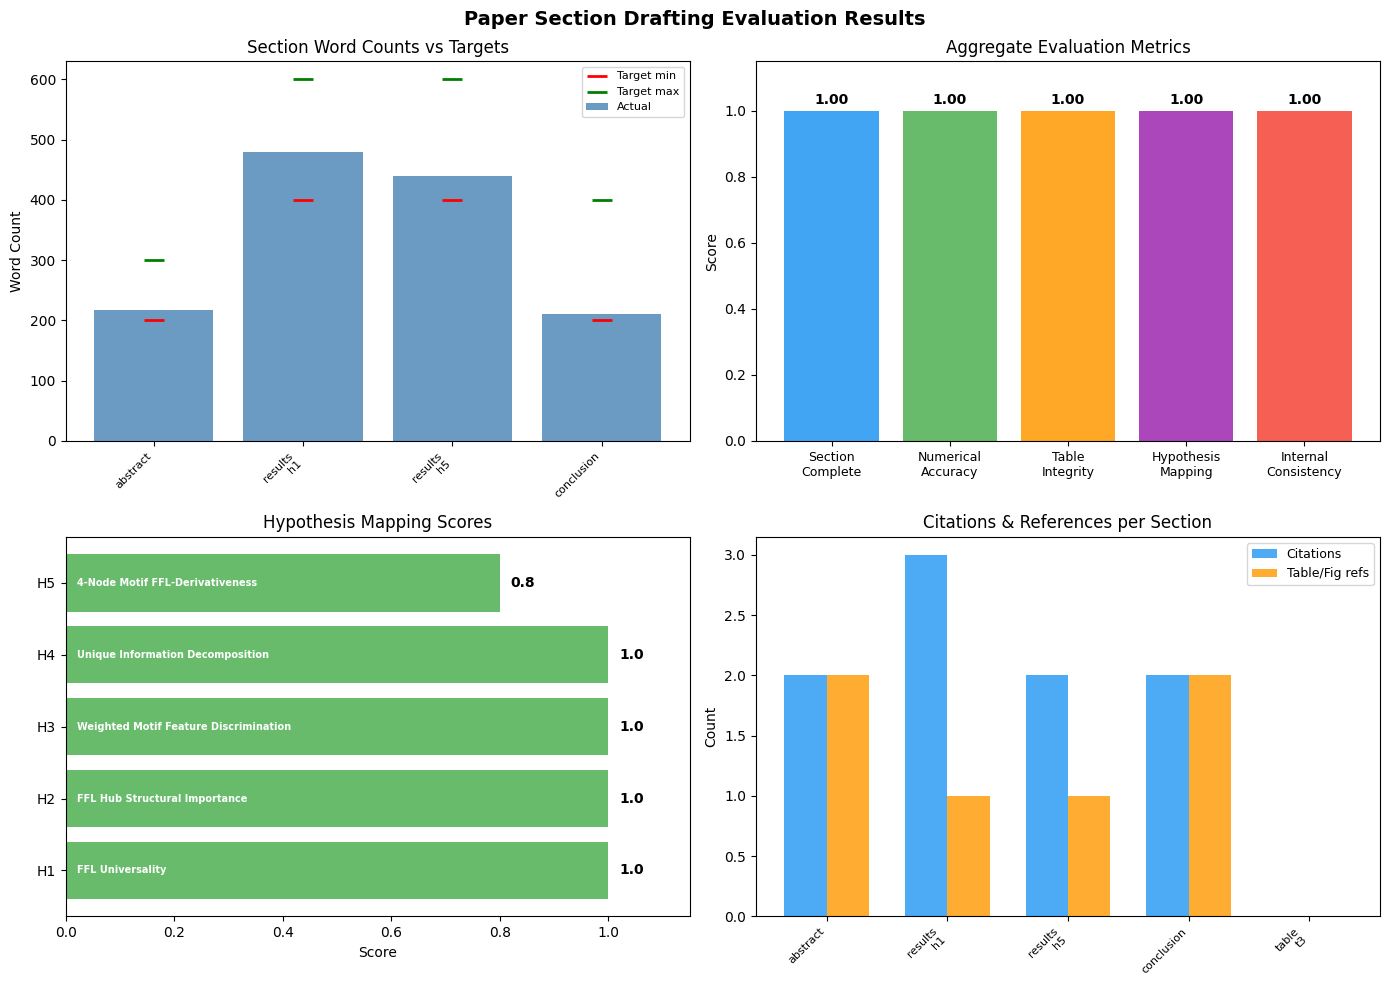

Visualization saved to evaluation_results.png


In [10]:
# ── Visualization ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Paper Section Drafting Evaluation Results", fontsize=14, fontweight='bold')

# --- Plot 1: Word counts vs target ranges ---
ax = axes[0, 0]
section_names = [r['section_name'] for r in section_results if not r['is_table']]
word_counts = [r['word_count'] for r in section_results if not r['is_table']]
targets_lo = [r['target_range'][0] for r in section_results if not r['is_table']]
targets_hi = [r['target_range'][1] for r in section_results if not r['is_table']]
x = np.arange(len(section_names))
ax.bar(x, word_counts, color='steelblue', alpha=0.8, label='Actual')
ax.scatter(x, targets_lo, marker='_', color='red', s=200, linewidths=2, zorder=5, label='Target min')
ax.scatter(x, targets_hi, marker='_', color='green', s=200, linewidths=2, zorder=5, label='Target max')
ax.set_xticks(x)
ax.set_xticklabels([s.replace('_', '\n') for s in section_names], fontsize=8, rotation=45, ha='right')
ax.set_ylabel('Word Count')
ax.set_title('Section Word Counts vs Targets')
ax.legend(fontsize=8)

# --- Plot 2: Aggregate metrics radar-style bar chart ---
ax = axes[0, 1]
metric_names = ['Section\nComplete', 'Numerical\nAccuracy', 'Table\nIntegrity',
                'Hypothesis\nMapping', 'Internal\nConsistency']
metric_vals = [metrics['section_completeness_avg'], metrics['numerical_claim_accuracy'],
               metrics['table_data_integrity'], metrics['hypothesis_mapping_coverage'],
               metrics['internal_consistency']]
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']
bars = ax.bar(range(len(metric_names)), metric_vals, color=colors, alpha=0.85)
ax.set_xticks(range(len(metric_names)))
ax.set_xticklabels(metric_names, fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Aggregate Evaluation Metrics')
for bar, val in zip(bars, metric_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')

# --- Plot 3: Hypothesis scores ---
ax = axes[1, 0]
hypo_ids = sorted(hypo_detail.keys())
hypo_scores = [hypo_detail[h]['score'] for h in hypo_ids]
hypo_colors = ['#4CAF50' if s >= 0.8 else '#FF9800' if s >= 0.6 else '#F44336' for s in hypo_scores]
bars = ax.barh(hypo_ids, hypo_scores, color=hypo_colors, alpha=0.85)
ax.set_xlim(0, 1.15)
ax.set_xlabel('Score')
ax.set_title('Hypothesis Mapping Scores')
for bar, val in zip(bars, hypo_scores):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=10, fontweight='bold')
# Add hypothesis descriptions
for i, hid in enumerate(hypo_ids):
    desc = hypo_mapping[hid].split('(')[0].strip()
    ax.text(0.02, i, desc, va='center', fontsize=7, color='white', fontweight='bold')

# --- Plot 4: Citations and references per section ---
ax = axes[1, 1]
section_names_all = [r['section_name'].replace('_', '\n') for r in section_results]
n_citations = [r['n_citations'] for r in section_results]
n_refs = [r['n_refs'] for r in section_results]
x = np.arange(len(section_names_all))
width = 0.35
ax.bar(x - width/2, n_citations, width, label='Citations', color='#2196F3', alpha=0.8)
ax.bar(x + width/2, n_refs, width, label='Table/Fig refs', color='#FF9800', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(section_names_all, fontsize=8, rotation=45, ha='right')
ax.set_ylabel('Count')
ax.set_title('Citations & References per Section')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('evaluation_results.png', dpi=100, bbox_inches='tight')
plt.show()
print("Visualization saved to evaluation_results.png")